In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [3]:
df=pd.read_csv('concrete_data.csv')

In [4]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [6]:
x=df.drop(['Strength'],axis=1)
y=df['Strength']

x_train,x_test,y_train,y_test=train_test_split(x,
                                                y,
                                                test_size=0.2,
                                                random_state=42)

In [7]:
#applying LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.6275531792314851

In [8]:
#cross val
cross_val_score(lr,x,y,scoring='r2').mean()

np.float64(0.4609940491662865)

<h1>Visualising the data distribution.</h1>

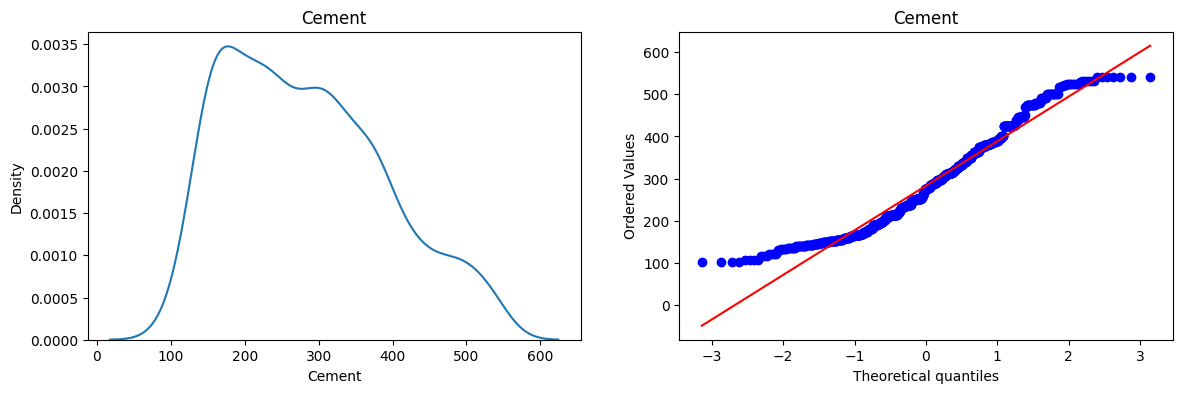

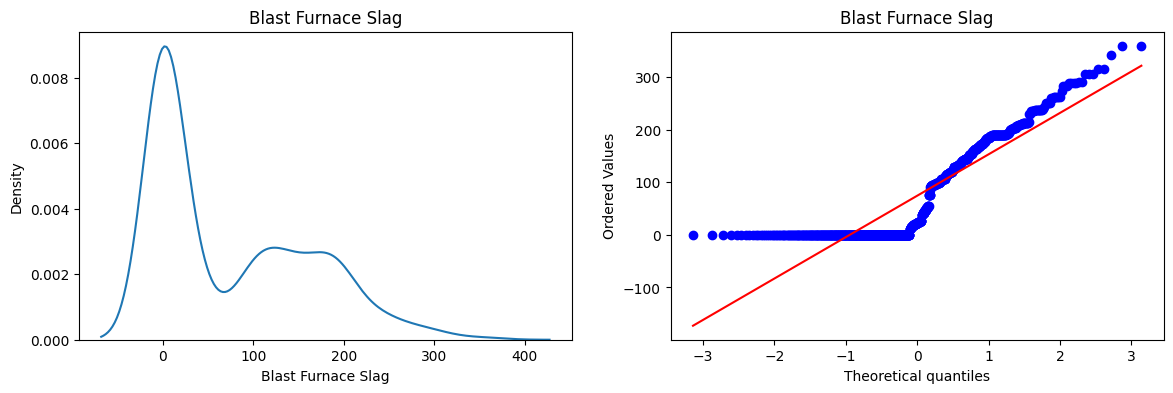

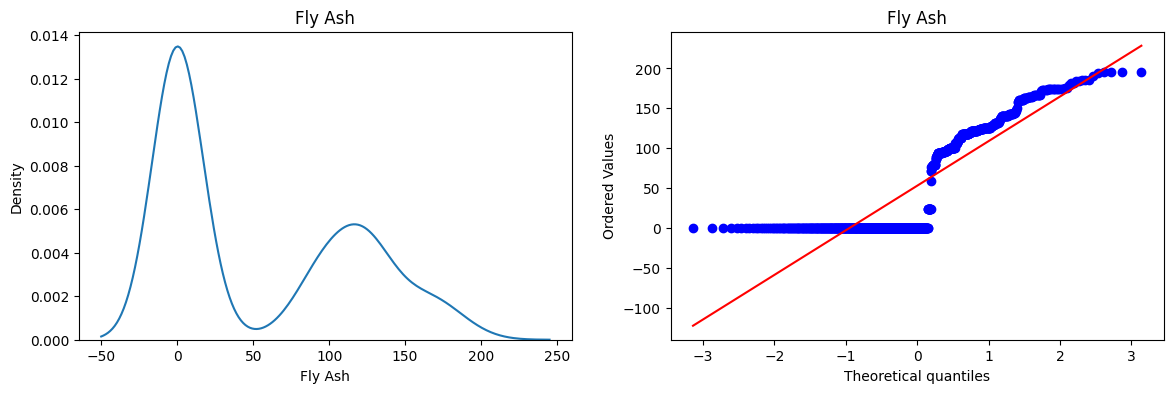

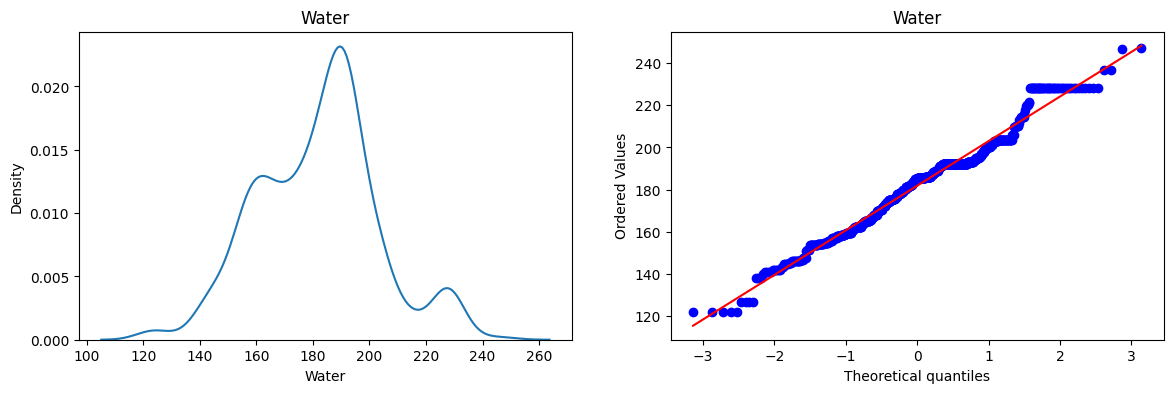

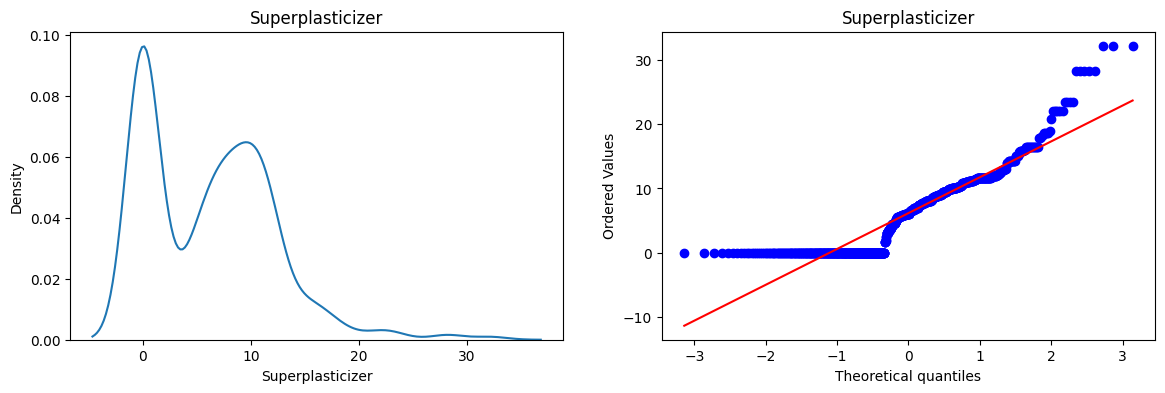

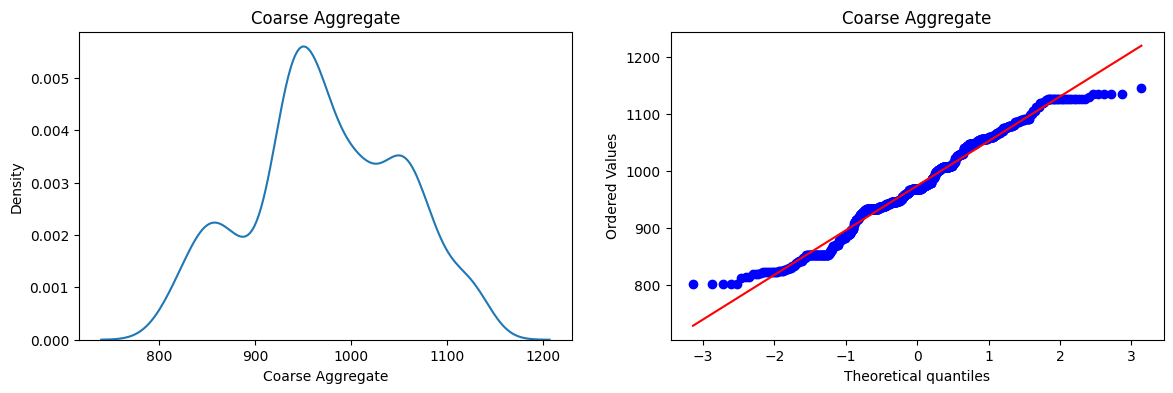

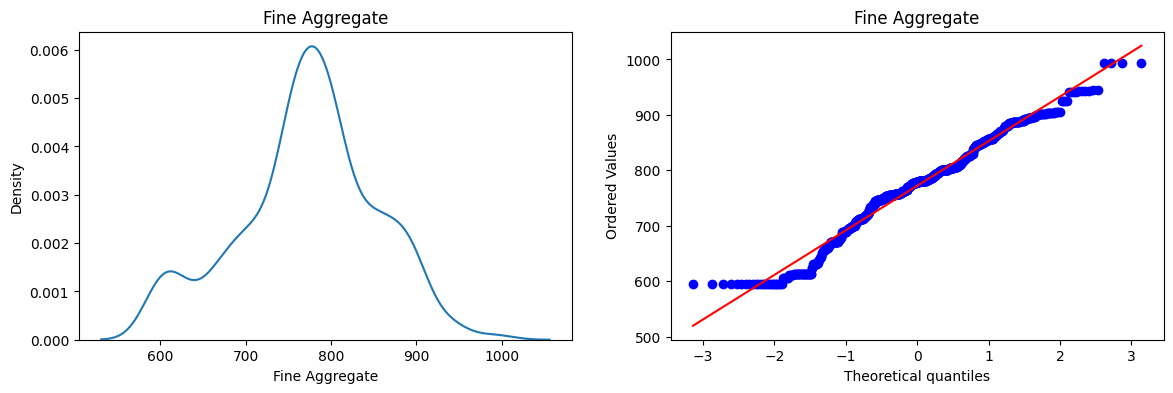

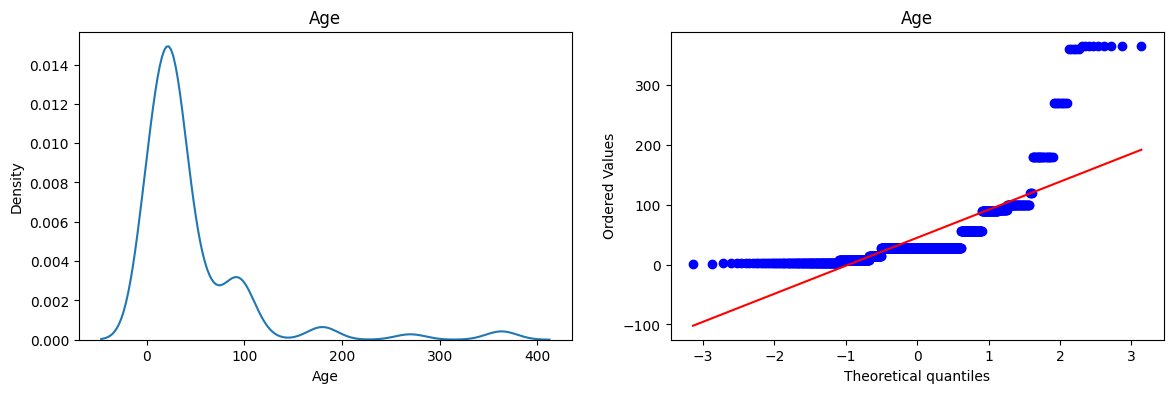

In [9]:
x_train_visual = pd.DataFrame(x_train,columns=x_train.columns)

for col in x_train_visual.columns:
    fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

    sns.kdeplot(x_train_visual[col],ax=ax1)
    ax1.set_title(col)

    stats.probplot(x_train_visual[col],dist='norm',plot=ax2)
    ax2.set_title(col)

<p>Here we see that maximum columns are not normally distributed, so we will apply box-cox and yeo-johnson transformations. Although as there is zero values present, more efficient will be yeo-johnson but we will try both.</p>

In [13]:
df.describe()
#notice the 0 values

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [10]:
#applying box-cox transformation
pt=PowerTransformer(method='box-cox') #default method is yeo-johnson

#adding a minimal value to deal with 0 values
x_train_transformed=pt.fit_transform(x_train+0.000001)
x_test_transformed=pt.transform(x_test+0.000001)

In [15]:
#viewing the lambda values for every column
pd.DataFrame({'cols':x_train.columns,'box-cox-lambdas':pt.lambdas_})

,cols,box-cox-lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [16]:
#applying Linear Regression on transformed data
lr=LinearRegression()
lr.fit(x_train_transformed,y_train)
y_pred2=lr.predict(x_test_transformed)
r2_score(y_test,y_pred2)

0.8047825008078887

In [37]:
x_transformed=pt.fit_transform(x+0.000001)
cross_val_score(lr,x_transformed,y,scoring='r2').mean()

np.float64(0.6662950326831084)

<h3>We notice a 0.2 improvement in model performance.</h3>

<h1>Visualising Before/After box-cox</h1>

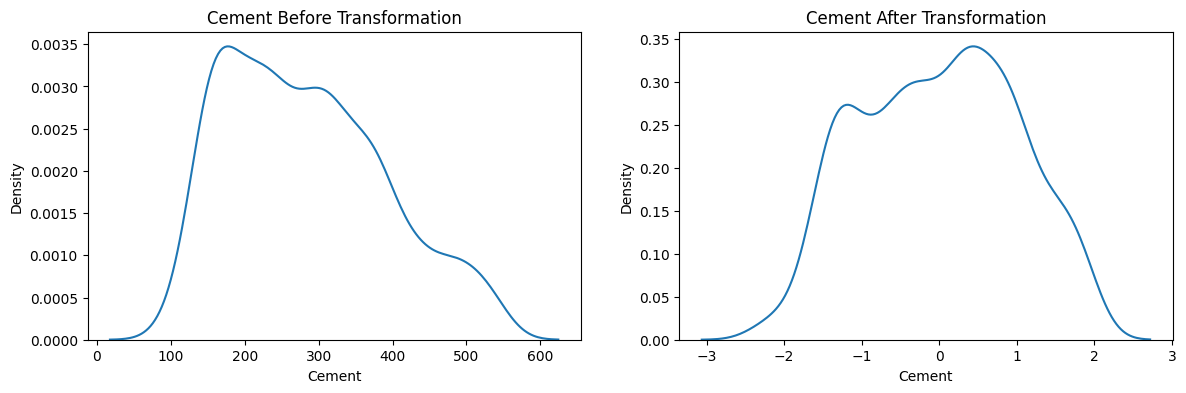

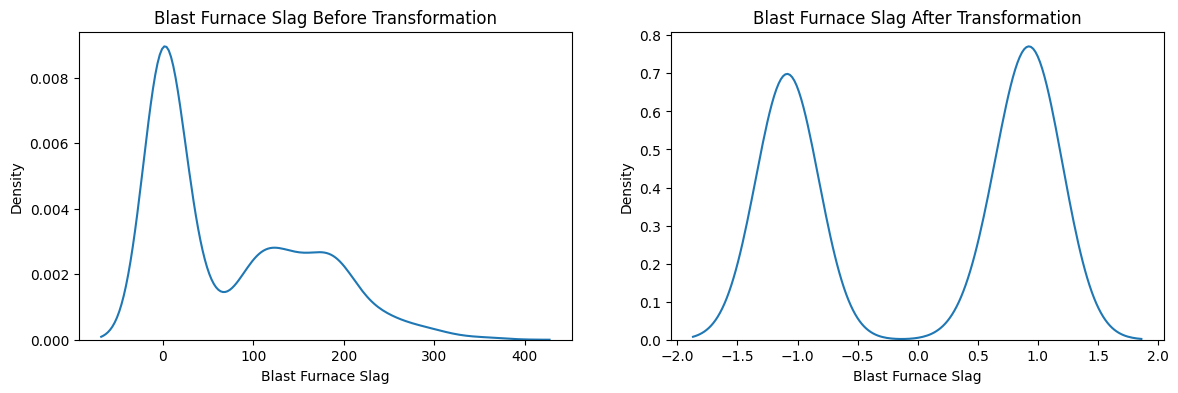

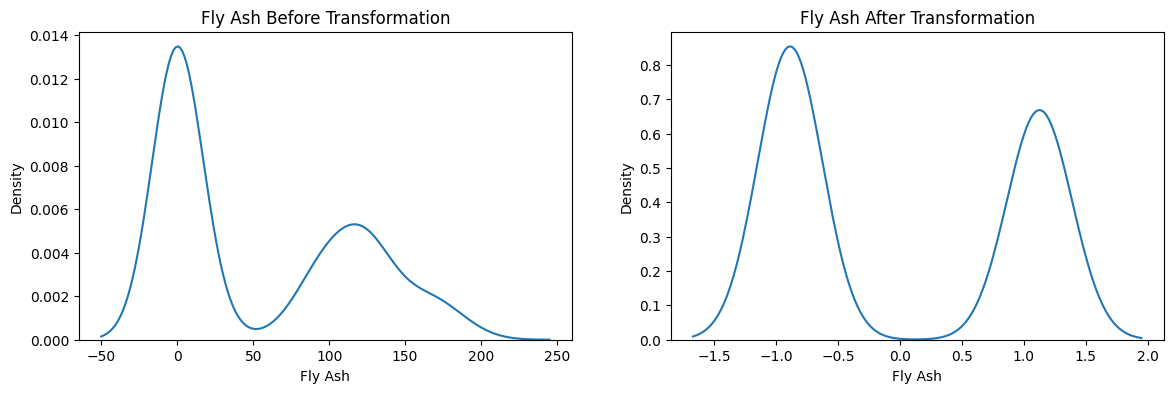

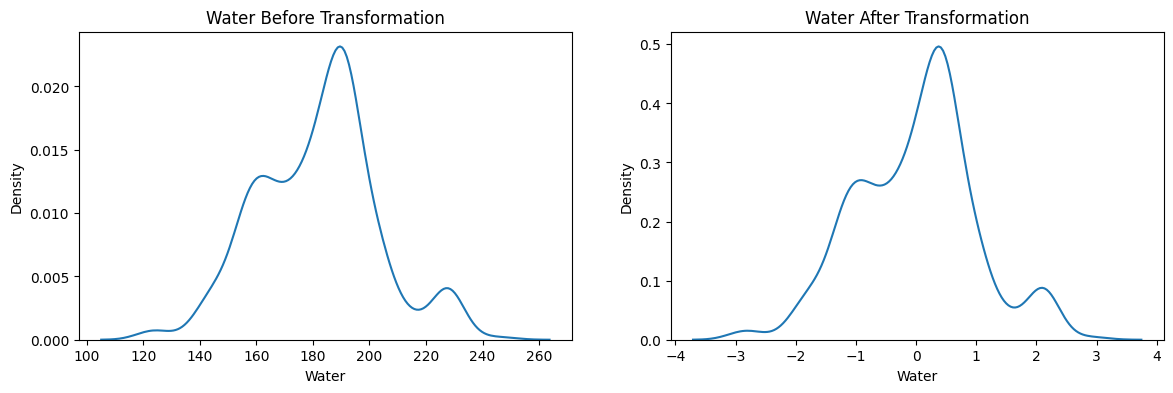

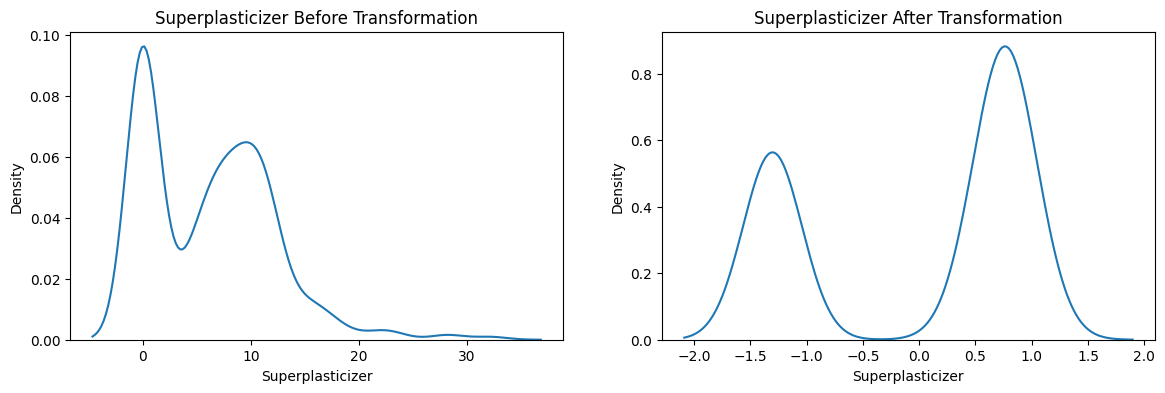

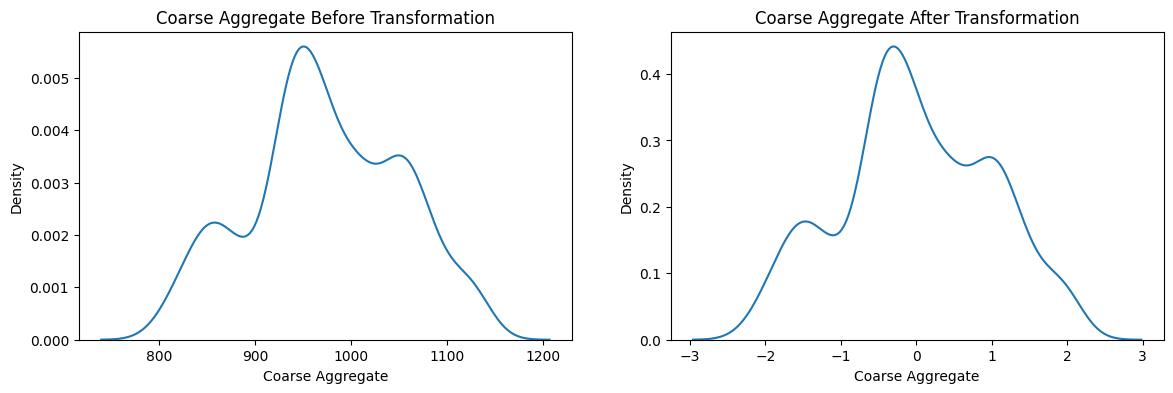

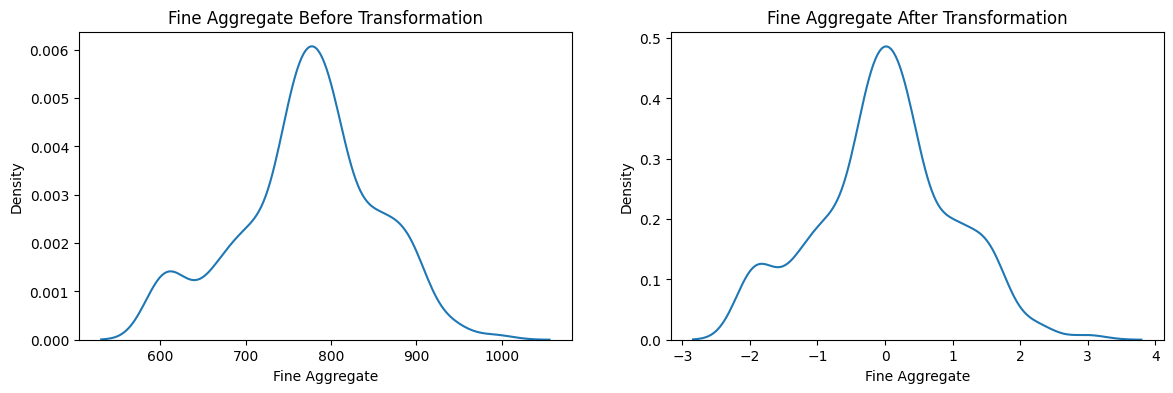

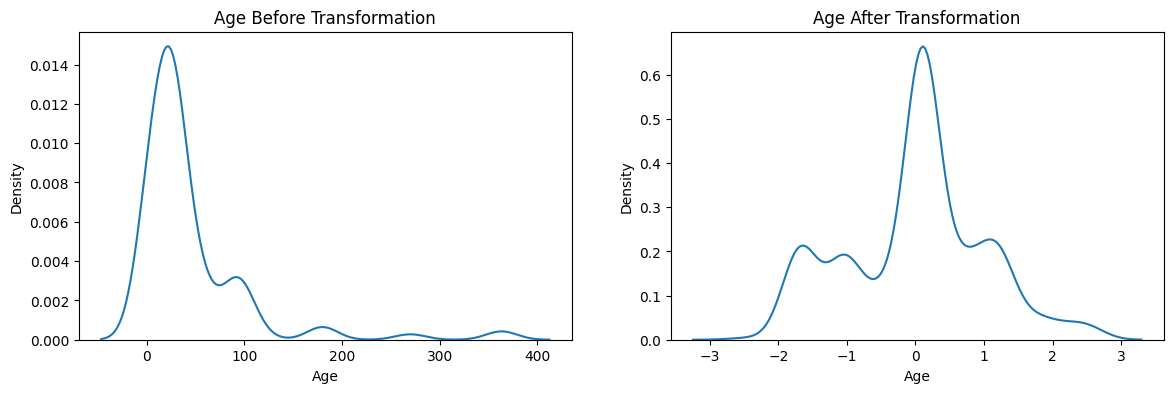

In [23]:
x_train_transformed_visual=pd.DataFrame(x_train_transformed,columns=x_train.columns)

for col in x_train_transformed_visual.columns:
    fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
    sns.kdeplot(x_train_visual[col],ax=ax1)
    ax1.set_title(col+' Before Transformation')

    sns.kdeplot(x_train_transformed_visual[col],ax=ax2)
    ax2.set_title(col+' After Transformation')

<p>We see significant normalisation of data in most of the columns.</p>

In [24]:
#applying yeo-johnson transform
pt2=PowerTransformer()
x_train_transformed2=pt2.fit_transform(x_train)
x_test_transformed2=pt2.transform(x_test)

In [25]:
#applying Linear Regression
lr=LinearRegression()
lr.fit(x_train_transformed2,y_train)

y_pred3=lr.predict(x_test_transformed2)
r2_score(y_test,y_pred3)

0.8161906511066099

In [26]:
pd.DataFrame({'cols':x_train.columns,'Yeo-Johnson_lambdas':pt2.lambdas_})

,cols,Yeo-Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [38]:
#applying cross val
x_transformed2=pt2.fit_transform(x)
cross_val_score(lr,x_transformed2,y,scoring='r2').mean()

np.float64(0.6834625126992433)

<h3>We notice an improvement in model accuracy again.</h3>

<h1>Visualising Before/After Yeo-Johnson</h1>

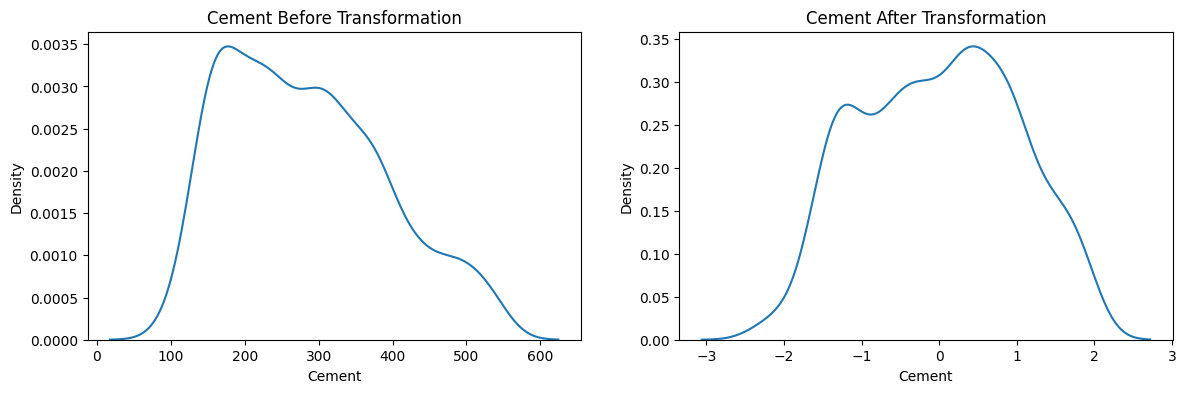

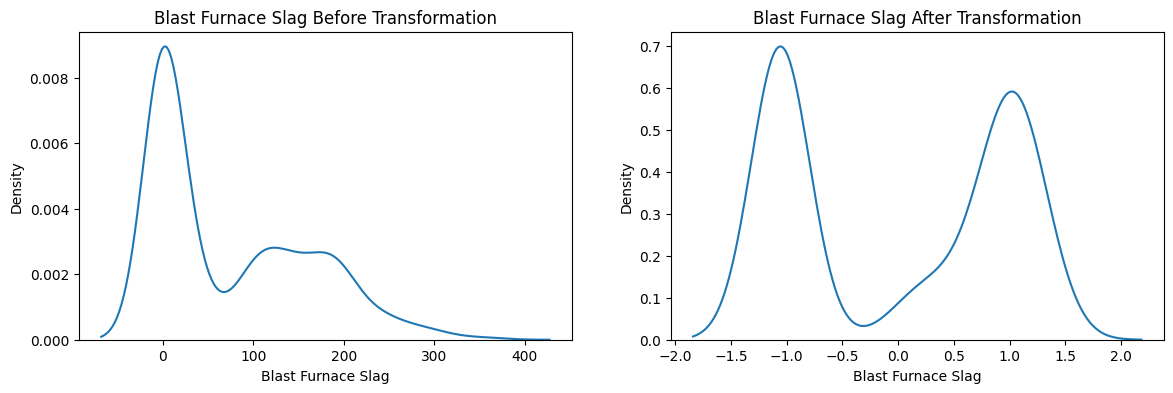

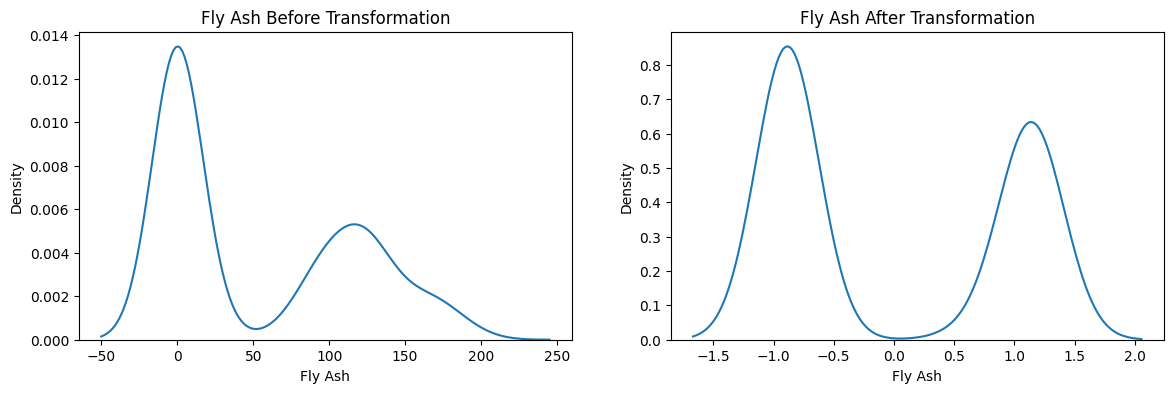

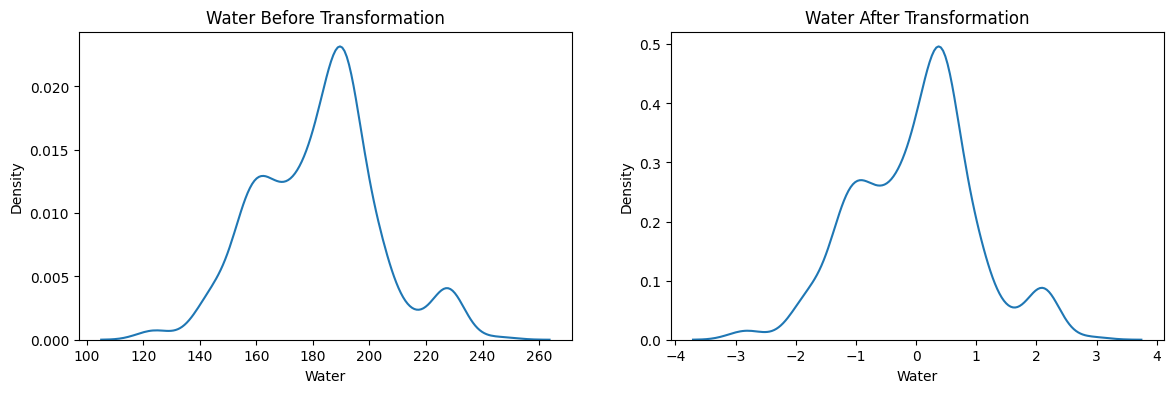

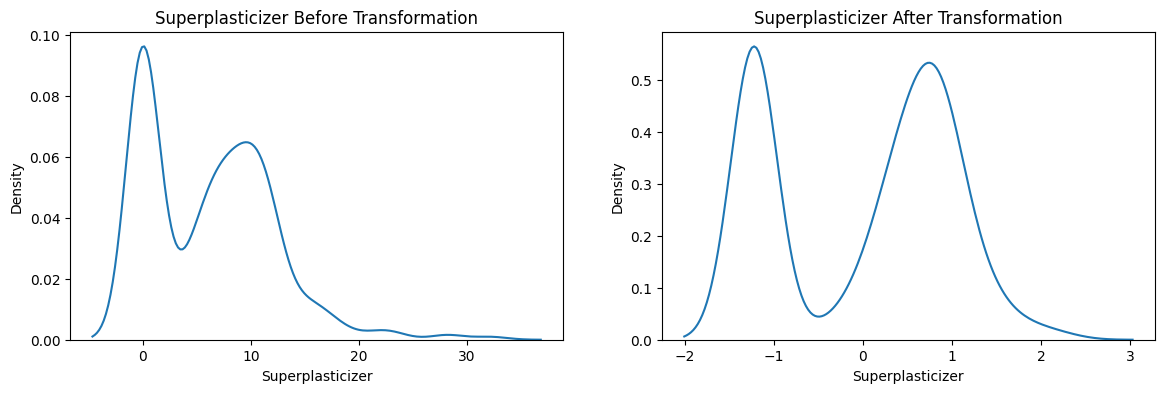

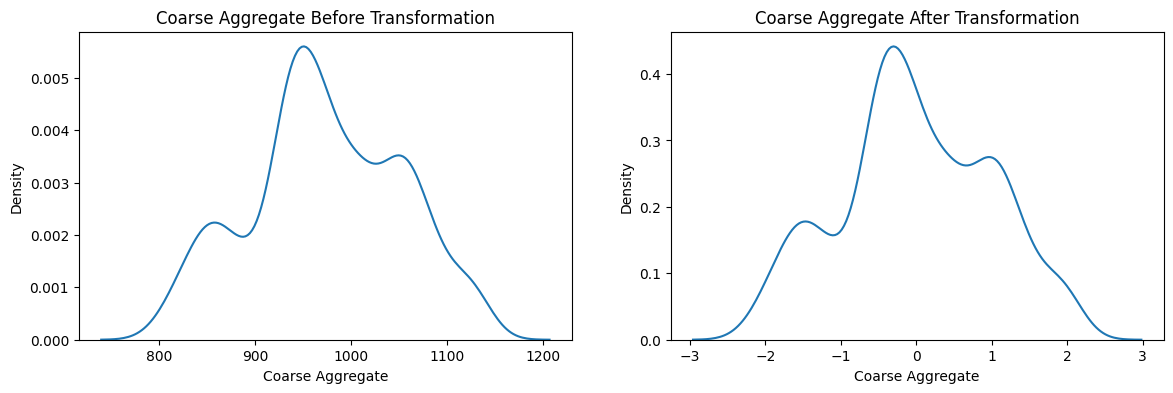

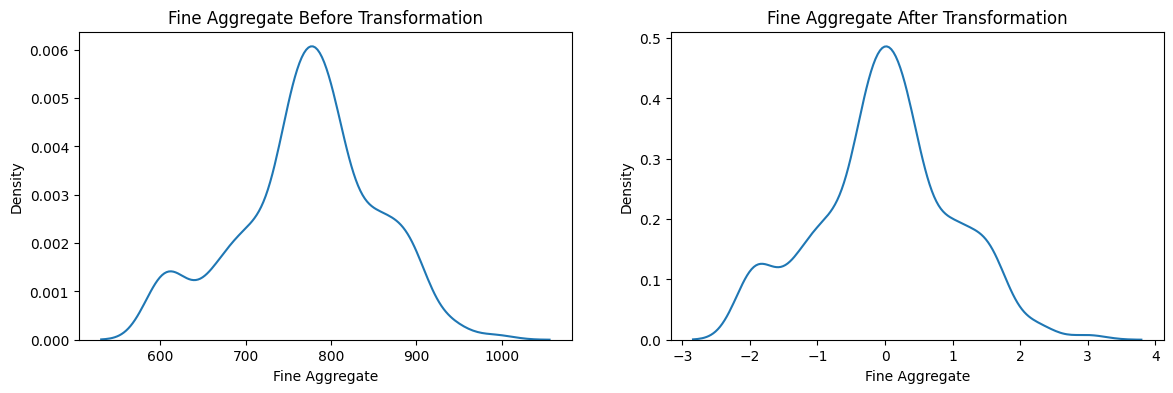

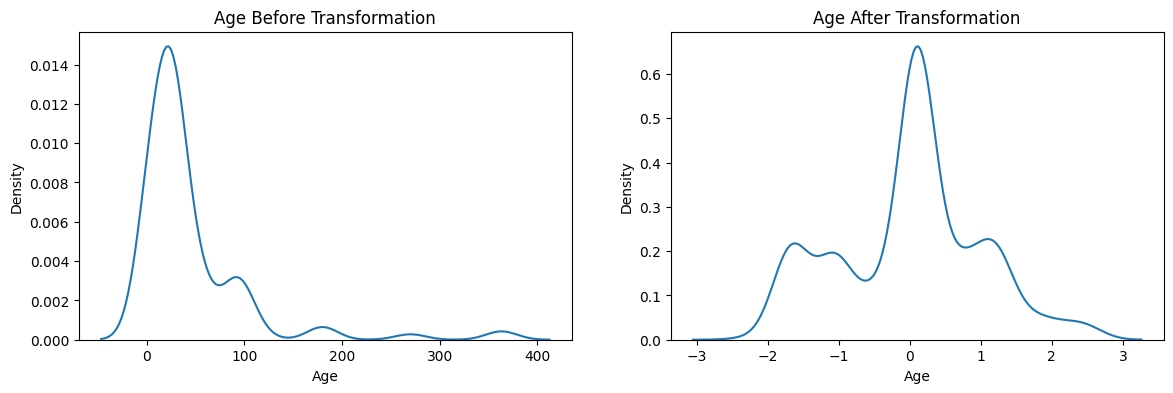

In [31]:
x_train_transformed2_visual=pd.DataFrame(x_train_transformed2,columns=x_train.columns)

for col in x_train_transformed2_visual.columns:
    fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
    sns.kdeplot(x_train[col],ax=ax1)
    ax1.set_title(col+" Before Transformation")

    sns.kdeplot(x_train_transformed2_visual[col],ax=ax2)
    ax2.set_title(col+ " After Transformation")

<p>We see significant normalisation of data in most of the columns.</p>